# Graph Mining
## Lab 7: Graph Neural Networks

1. Data exploration and homophily on the Cora citation network.
2. Feature-only baselines: Logistic Regression and MLP.
3. Graph Convolutional Network (GCN).
4. Oversmoothing.
5. GraphSAGE and parameter analysis.
6. Image classification: MLP vs CNN vs GNN on MNIST.

## Installation

In [32]:
%pip install torch torchvision --quiet
%pip install torch_geometric scikit-learn --quiet
%pip install scikit-network --quiet

## Import

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE

import torch
import torch.nn.functional as F
from torch import nn
from torch.nn import Linear
from torch.utils.data import DataLoader as TorchDataLoader, Subset

from torchvision import datasets, transforms

from torch_geometric.datasets import Planetoid
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, SAGEConv

torch.manual_seed(42)

ModuleNotFoundError: No module named 'torch'

---
## 1. The Cora Dataset

Cora is a citation network: nodes are papers, edges are citations.
Each node has a bag-of-words feature vector ($d_0 = 1433$) and one of $C = 7$ topic labels.
Labels are provided for only 140 nodes out of 2708 (semi-supervised setting).

| Attribute | Shape | Content |
|-----------|-------|---------|
| `data.x` | `[2708, 1433]` | Bag-of-words features |
| `data.edge_index` | `[2, 10556]` | Directed edges in COO format (5278 undirected) |
| `data.y` | `[2708]` | Topic labels (0-6) |
| `data.train_mask` | `[2708]` | 140 training nodes |

The **homophily ratio** is the fraction of edges connecting nodes of the same class:
$$h = \frac{|\{(u,v) \in E : y_u = y_v\}|}{|E|}$$
A ratio close to 1 means neighbours tend to share the same label.

In [34]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

print(f"Nodes:           {data.num_nodes}")
print(f"Undirected edges:{data.num_edges // 2}")
print(f"Node features:   {data.num_node_features}")
print(f"Classes:         {dataset.num_classes}")
print(f"Training nodes:  {data.train_mask.sum().item()}")
print(f"Val nodes:       {data.val_mask.sum().item()}")
print(f"Test nodes:      {data.test_mask.sum().item()}")

row, col = data.edge_index
# TODO 1: compute the homophily ratio h and print it

Nodes:           2708
Undirected edges:5278
Node features:   1433
Classes:         7
Training nodes:  140
Val nodes:       500
Test nodes:      1000


**Question 1.** What is the homophily ratio of Cora?
What does it imply for message-passing GNNs?

 **Answer**: The homophily ratio is approximately 0.81. That implies that, for a node, its neighbors will probably reinforce the same features during the aggregation.

In [35]:
# compute common classes nodes
same_class = 0
for source, target in zip(row, col):
    source_label = data.y[source]
    target_label = data.y[target]
    if source_label == target_label:
      same_class += 1

# compute h
h = same_class/len(row)
print(f"The homophily ratio of cora is {h}")


The homophily ratio of cora is 0.8099658961727927


---
## 2. Baselines

Three baselines on Cora: **Logistic Regression** and **MLP** use only node features (no graph); **Heat Diffusion** uses graph structure but learns no parameters.

In [36]:
X_train = data.x[data.train_mask].numpy()
y_train = data.y[data.train_mask].numpy()
X_test  = data.x[data.test_mask].numpy()
y_test  = data.y[data.test_mask].numpy()

# TODO 2: fit a LogisticRegression (max_iter=1000)
# store train accuracy in lr_train_acc and test accuracy in lr_acc
# print both - done

In [37]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_train_acc = lr.score(X_train, y_train)
lr_acc = lr.score(X_test, y_test)
print(f"Train accuracy {lr_train_acc} | Test accuracy {lr_acc}")

Train accuracy 1.0 | Test accuracy 0.576


### MLP

An MLP with the same depth and hidden dimension as the GCN in Section 3,
but without any graph aggregation.

## To do

* Implement the `forward` method of `MLP`:
  apply `lin1`, ReLU, dropout, then `lin2`.

In [38]:
class MLP(nn.Module):
    def __init__(self, in_ch, hidden, out_ch, dropout=0.5):
        super().__init__()
        self.lin1 = Linear(in_ch, hidden)
        self.lin2 = Linear(hidden, out_ch)
        self.dropout = dropout


    def forward(self, x):
        # TODO 3: implement the forward pass of MLP - done
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)
        return x

def train_mlp(model, data, opt):
    model.train(); opt.zero_grad()
    out  = model(data.x)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward(); opt.step()
    return loss.item()

@torch.no_grad()
def eval_mlp(model, data):
    model.eval()
    pred = model(data.x).argmax(1)
    return {s: (pred[data[f'{s}_mask']] == data.y[data[f'{s}_mask']]).float().mean().item()
            for s in ('train', 'val', 'test')}


mlp = MLP(dataset.num_features, 64, dataset.num_classes)
opt = torch.optim.Adam(mlp.parameters(), lr=0.01, weight_decay=5e-4)
for _ in range(200):
    train_mlp(mlp, data, opt)
mlp_res = eval_mlp(mlp, data)
mlp_acc = mlp_res['test']
print(f"MLP                  train acc: {mlp_res['train']:.4f}  test acc: {mlp_acc:.4f}")

MLP                  train acc: 1.0000  test acc: 0.5850


**Question 2.** Compare the train and test accuracy of LR and MLP.
Does the MLP benefit from having more parameters than LR?
What does this suggest about the features alone?

**Answer**: Both train accuracies achieve 100%, but the test accuracy of LR is higher than MLP's (58% > 57%). Thus, the MLP does not benefit from having more parameters. Also, it seems that features do not reveal much about true nature of data, as it gives us bad test accuracies for both models and MLP cannot generalize, even by having more parameters.

### Heat Diffusion

`DiffusionClassifier` from `sknetwork` propagates label "temperature" from the 140 labeled nodes across edges for `n_iter` steps, then assigns each node the label of highest temperature. It uses graph structure but learns no parameters.

In [39]:
print(data.num_nodes)

2708


In [40]:
from scipy.sparse import csr_matrix
from sknetwork.classification import DiffusionClassifier
from sklearn.metrics import accuracy_score

adjacency = np.zeros((data.num_nodes, data.num_nodes))
for (s, t) in zip(row, col):
  adjacency[s][t] = 1

adjacency = csr_matrix(adjacency)

# pass only train nodes  !!!!
train_labels = -np.ones(data.num_nodes, dtype=int)
train_labels[data.train_mask] = data.y[data.train_mask]

# TODO 4: compute diff_train_acc (train mask) and diff_acc (test mask), then print both - done
diffusion = DiffusionClassifier()
labels_pred = diffusion.fit_predict(adjacency, train_labels)
diff_train_acc = (labels_pred[data.train_mask] == y_train).mean()
diff_acc = (labels_pred[data.test_mask] == y_test).mean()
print(f"Train accuracy: {diff_train_acc}")
print(f"Test accuracy: {diff_acc}")


Train accuracy: 1.0
Test accuracy: 0.684


**Question 3.** Compare the test accuracy of Heat Diffusion to LR and MLP. Comment on what this tells you.

**Answer**: We achieved with Diffusion, the highest accuracy between all models. We realize that the features are way worst than the graph structure for this problem. Also, the fact of the graph being homophilic probably helped the Diffusion classifierr.

---
## 3. Graph Convolutional Network

Each GCN layer computes (lecture, Definition 3.1):
$$H^{(l+1)} = \sigma\!\left(\hat{A}\, H^{(l)}\, W^{(l)}\right), \quad \hat{A} = \tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$$

`GCNConv(in_ch, out_ch)` in PyG computes one such layer.

## To do

* Implement the `forward` method of `GCN`:
  apply `conv1` + ReLU + dropout, then `conv2`.

GCN  train acc: 1.0000  test acc: 0.8010


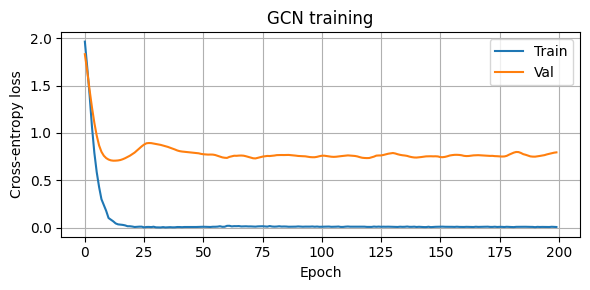

In [41]:
class GCN(nn.Module):
    def __init__(self, in_ch, hidden, out_ch, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, out_ch)
        self.dropout = dropout

    def forward(self, x, edge_index):
        # TODO 5: implement the forward pass of GCN - done
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


def train_step(model, data, opt):
    model.train(); opt.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward(); opt.step()
    return loss.item()

@torch.no_grad()
def node_val_loss(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    return F.cross_entropy(out[data.val_mask], data.y[data.val_mask]).item()

@torch.no_grad()
def evaluate(model, data):
    model.eval()
    pred = model(data.x, data.edge_index).argmax(1)
    return {s: (pred[data[f'{s}_mask']] == data.y[data[f'{s}_mask']]).float().mean().item()
            for s in ('train', 'val', 'test')}


gcn = GCN(dataset.num_features, 64, dataset.num_classes)
opt = torch.optim.Adam(gcn.parameters(), lr=0.01, weight_decay=5e-4)
train_losses, val_losses = [], []
for _ in range(200):
    train_losses.append(train_step(gcn, data, opt))
    val_losses.append(node_val_loss(gcn, data))
gcn_res = evaluate(gcn, data)
gcn_train_acc, gcn_acc = gcn_res['train'], gcn_res['test']
print(f"GCN  train acc: {gcn_train_acc:.4f}  test acc: {gcn_acc:.4f}")

plt.figure(figsize=(6, 3))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss')
plt.title('GCN training')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

**Question 4.** How much does the GCN improve over the baselines?
What does this tell you about the role of graph structure?

**Answer**: The GCN performance is the best so far (80%) which beats LR, MLP and Diffusion (58%, 57%, 68%, respectively). Indeed, the graph structure is extremely relevant for helping our classifiers. We already had an insight about this after running the Diffusion model, but now it is confirmed that the features alone are not enough.

### Node Embedding Comparison

**t-SNE** (*t-distributed Stochastic Neighbor Embedding*) is a dimensionality reduction method used to visualize high-dimensional data in 2D or 3D by placing similar points close together.

Reference: [scikit-learn t-SNE documentation](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

## To do

* Implement `layer1_embeddings`: given a model and a flag `is_gcn`,
  extract the output of the first layer (after ReLU) as a numpy array.
  - GCN: `model.conv1(data.x, data.edge_index).relu()`
  - MLP: `model.lin1(data.x).relu()`
* Plot the t-SNE projections of MLP and GCN layer-1 embeddings side by side,
  colouring each point by its true class label (`data.y`).

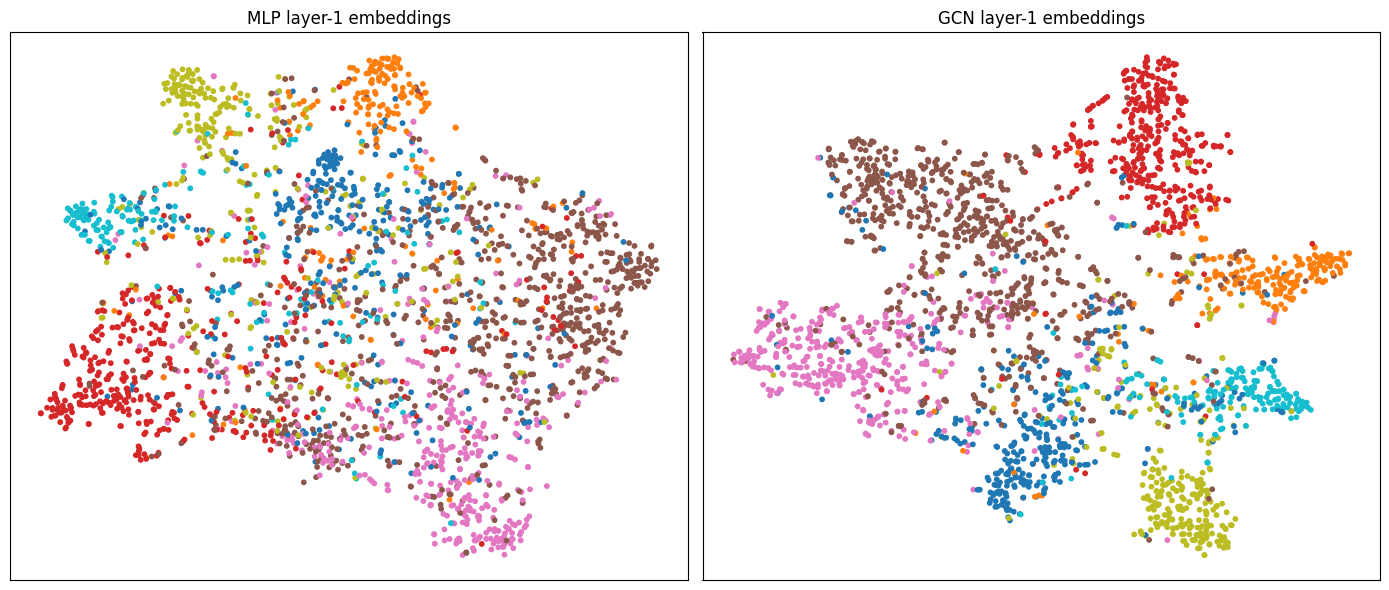

In [42]:
@torch.no_grad()
def layer1_embeddings(model, data, is_gcn):
    model.eval()
    # TODO - done
    if is_gcn:
      h = model.conv1(data.x, data.edge_index)
    else:
      h = model.lin1(data.x)
    h = F.relu(h)

    return h.cpu().numpy()

mlp_emb = layer1_embeddings(mlp, data, is_gcn=False)
gcn_emb = layer1_embeddings(gcn, data, is_gcn=True)

tsne = TSNE(
    n_components=2,
    random_state=0,
    init="pca"
)

mlp_2d = tsne.fit_transform(mlp_emb)
gcn_2d = tsne.fit_transform(gcn_emb)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# TODO 6: plot t-SNE projections of MLP and GCN layer-1 embeddings, coloured by true class - done
axes[0].scatter(
    mlp_2d[:, 0],
    mlp_2d[:, 1],
    c=data.y.numpy(),
    cmap="tab10",
    s=10
)
axes[0].set_title("MLP layer-1 embeddings")

axes[1].scatter(
    gcn_2d[:, 0],
    gcn_2d[:, 1],
    c=data.y.numpy(),
    cmap="tab10",
    s=10
)
axes[1].set_title("GCN layer-1 embeddings")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

**Question 5.** Compare the two t-SNE plots.
What does the difference in cluster structure tell you about the effect of
graph aggregation on the node representations?

**Answer**: We observe that GCN embeddings have much more clear are separated clusters. The graph aggregation performed to compute these embeddings was crucial to explore the graph structure and homophilia, leading to a much more precise plot.

---
## 4. Oversmoothing

Deeper neural networks learn more complex functions, so we should increase the number of layers to improve performance, right?

In [43]:
class DeepGCN(nn.Module):
    def __init__(self, in_ch, hidden, out_ch, K, dropout=0.5):
        super().__init__()
        if K == 1: # Addition this small fix, because K=1 and K=2 were giving the same architecture before
            self.convs = nn.ModuleList([GCNConv(in_ch, out_ch)])
        else:
            self.convs = nn.ModuleList([GCNConv(in_ch, hidden)])
            for _ in range(K - 2):
                self.convs.append(GCNConv(hidden, hidden))
            self.convs.append(GCNConv(hidden, out_ch))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index).relu()
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

## To do

* For each depth $K$ in `[1, 2, 3, 4, 5, 6, 8, 10, 12]`:
  * Instantiate a `DeepGCN` model.
  * Train for 200 epochs with `Adam(lr=0.01, weight_decay=5e-4)`.
  * Record train, val, and test accuracy.
* Plot all three curves against depth.

K= 1  train=1.0000  val=0.7380  test=0.7480
K= 2  train=1.0000  val=0.7740  test=0.8040
K= 3  train=1.0000  val=0.7540  test=0.7950
K= 4  train=1.0000  val=0.7480  test=0.7830
K= 5  train=1.0000  val=0.7720  test=0.7760
K= 6  train=1.0000  val=0.7700  test=0.7750
K= 8  train=1.0000  val=0.7740  test=0.7780
K=10  train=1.0000  val=0.7180  test=0.6980
K=12  train=0.6214  val=0.4980  test=0.5140


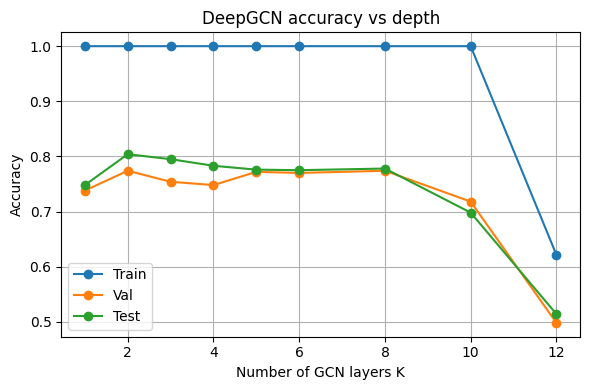

In [44]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 12]
train_accs, val_accs, test_accs = [], [], []

for K in depths:
    # TODO: train DeepGCN with K layers and record train/val/test accuracy - done
    model = DeepGCN(dataset.num_features, 64, dataset.num_classes, K)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    for epoch in range(200):
        train_step(model, data, opt)

    res = evaluate(model, data)

    train_accs.append(res["train"])
    val_accs.append(res["val"])
    test_accs.append(res["test"])

    print(f"K={K:2d}  train={res['train']:.4f}  val={res['val']:.4f}  test={res['test']:.4f}")

# TODO 7: plot train, val, test accuracy vs depth - done
plt.figure(figsize=(6, 4))

plt.plot(depths, train_accs, marker="o", label="Train")
plt.plot(depths, val_accs, marker="o", label="Val")
plt.plot(depths, test_accs, marker="o", label="Test")

plt.xlabel("Number of GCN layers K")
plt.ylabel("Accuracy")
plt.title("DeepGCN accuracy vs depth")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Question 6.** At which depth does accuracy peak?
What happens to accuracy as $K$ grows?
Explain this phenomenon.

**Answer**: The highest test accuracy was for K=3. We observe accuracy decaying after that K, for both validation and test. Even for the train, the accuracy starts dropping at K=6. This happens due to Oversmoothing. After K=3, the averaging of neighbors start to reduce the discriminative power of the embeddings, making more difficuld for the model to correctly predict classes.

---
## 5. GraphSAGE

GraphSAGE keeps separate weight matrices for the node's own embedding and the
neighbourhood aggregation (lecture, Definition 3.4):
$$h_v^{(l+1)} = \sigma\!\left(\left[h_v^{(l)} \,\Vert\, \frac{1}{d_v}\sum_{u \in \mathcal{N}(v)} h_u^{(l)}\right] W^{(l)}\right)$$

`SAGEConv(in_ch, out_ch)` in PyG implements this layer.

## To do

* Implement the `__init__` method of `GraphSAGE`:
  two `SAGEConv` layers (in→hidden, hidden→out) plus a `dropout` attribute.
* Implement the `forward` method:
  same structure as GCN but using `SAGEConv` layers.

In [45]:
class GraphSAGE(nn.Module):
    def __init__(self, in_ch, hidden, out_ch, dropout=0.5):
        # TODO - done
        super().__init__()
        self.conv1 = SAGEConv(in_ch, hidden)
        self.conv2 = SAGEConv(hidden, out_ch)
        self.dropout = dropout


    def forward(self, x, edge_index):
        # TODO 8: implement the forward pass of GraphSAGE - done
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

sage = GraphSAGE(dataset.num_features, 64, dataset.num_classes)
opt  = torch.optim.Adam(sage.parameters(), lr=0.01, weight_decay=5e-4)
for _ in range(200):
    train_step(sage, data, opt)
sage_res = evaluate(sage, data)
sage_train_acc, sage_acc = sage_res['train'], sage_res['test']
print(f"GraphSAGE  train acc: {sage_train_acc:.4f}  test acc: {sage_acc:.4f}")

GraphSAGE  train acc: 1.0000  test acc: 0.8060


In [46]:
dataset.num_classes

7

**Question 7.** How does GraphSAGE compare to GCN in accuracy?


**Answer**: GraphSAGE has 79.9% while GCN has 80.10%, therefore GCN is better by a little margin.

### Parameter Count

**Question.** Compare the number of trainable parameters in MLP, GCN, and GraphSAGE.
- Explain why MLP and GCN have the same count despite their different architectures.
- Justify GraphSAGE's count by detailing the parameter breakdown for each layer.

**Answer**: We know that MLP and GCN have the same count because the inductive bias introduced in GCN is a process that do not require new trainable parameters, it depends only on the product $ \hat{A}H^{(l)}$.

For GraphSAGE's count, the concatenation of the node own information with its neighbor's increases the count to almost two times more. We can detail the parameter countdown like this:

For the first layer, $\text{SAGEConv(1433, 64)}$:

$$
1433 \times 64 = 91\,712
$$

parameters are used for the self-transformation and

$$
1433 \times 64 = 91\,712
$$

parameters are used for the neighborhood transformation.
Adding the bias term of size $64$ gives

$$
91\,712 + 91\,712 + 64
=
183\,488
$$

parameters.

For the second layer, $\texttt{SAGEConv(64, 7)}$:

$$
64 \times 7 = 448
$$

parameters are used for the self-transformation and

$$
64 \times 7 = 448
$$

for the neighborhood transformation.
Including the bias term of size $7$ gives

$$
448 + 448 + 7
=
903
$$

parameters.

Therefore, the total number of trainable parameters in the GraphSAGE
model is

$$
183\,488 + 903
=
184\,391.
$$

Since the GCN with the same hidden dimension uses a single
weight matrix per layer and therefore contains approximately half as
many parameters.

In [47]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

# TODO 9: count and print the number of parameters in MLP, GCN, and GraphSAGE - done
mlp_params = count_params(mlp)
gcn_params = count_params(gcn)
sage_params = count_params(sage)
print(f"  MLP:   {mlp_params}\n  GCN:   {gcn_params}\n  SAGE: {sage_params}")

  MLP:   92231
  GCN:   92231
  SAGE: 184391


In [48]:
# You have to run all the code above and use the same variables name
# for the final comparison table - done

print(f"{'Model':<22} {'Train acc':>10} {'Test acc':>10}")
print("-" * 44)
for name, tr, te in [
        ('Logistic Regression', lr_train_acc,    lr_acc),
        ('MLP (no graph)',      mlp_res['train'], mlp_acc),
        ('Heat Diffusion',      diff_train_acc,  diff_acc),
        ('GCN',                 gcn_train_acc,    gcn_acc),
        ('GraphSAGE',           sage_train_acc,   sage_acc),
    ]:
    print(f"{name:<22} {tr:>10.4f} {te:>10.4f}")

Model                   Train acc   Test acc
--------------------------------------------
Logistic Regression        1.0000     0.5760
MLP (no graph)             1.0000     0.5850
Heat Diffusion             1.0000     0.6840
GCN                        1.0000     0.8010
GraphSAGE                  1.0000     0.8060


**Question 8.** Looking at the full comparison table, what is the effect of using graph structure?

**Answer**: It is clear that graph structure has a crucial role on contextualizing the node features within a node's position inside the graph. The accuracy go up as soon as we started doing this.

---
## 6. Image Classification: MLP vs CNN vs GNN

MNIST digits are defined on a regular 28x28 pixel grid.
Each image is converted to a graph: each pixel is a node, connected to its
4 grid neighbours (up, down, left, right).

## To do

* Implement `image_to_graph`: build node features
  $[\text{intensity}, x/27, y/27]$ and return a `Data` object.
* Implement the `forward` method of `MNISTGraphNet`:
  apply 3 GCN layers with ReLU and dropout, then flatten all node embeddings
  to shape $[784 \times \text{hidden}]$ and pass through the final linear layer.

In [49]:
def make_grid_edges(h=28, w=28):
    src, dst = [], []
    for i in range(h):
        for j in range(w):
            n = i * w + j
            if j + 1 < w:
                src += [n, n + 1]; dst += [n + 1, n]
            if i + 1 < h:
                src += [n, n + w]; dst += [n + w, n]
    return torch.tensor([src, dst], dtype=torch.long)

GRID_EDGES = make_grid_edges()

def image_to_graph(img, label):
    # TODO 10: convert a 28x28 image to a graph Data object with node features [intensity, x_pos, y_pos] - done
    intensity = img.view(-1, 1)                                         # [784, 1]

    x_pos = (torch.arange(28).repeat(28).view(-1, 1).float()) / 27          # [784, 1]
    y_pos = (torch.arange(28).repeat_interleave(28).view(-1, 1).float()) / 27

    feats = torch.cat([intensity, x_pos, y_pos], dim=1)                 # [784, 3]

    return Data(x=feats, edge_index=GRID_EDGES.clone(), y=torch.tensor([label]))

print(f"Grid edges per image: {GRID_EDGES.shape[1] // 2} undirected")

Grid edges per image: 1512 undirected


In [50]:
transform = transforms.ToTensor()
raw_train = datasets.MNIST('/tmp/MNIST', train=True,  download=True, transform=transform)
raw_test  = datasets.MNIST('/tmp/MNIST', train=False, download=True, transform=transform)

N_TRAIN, N_VAL, N_TEST = 1600, 400, 500
print("Converting images to graphs...")
train_graphs = [image_to_graph(img, lbl) for img, lbl in list(raw_train)[:N_TRAIN]]
val_graphs   = [image_to_graph(img, lbl) for img, lbl in list(raw_train)[N_TRAIN:N_TRAIN + N_VAL]]
test_graphs  = [image_to_graph(img, lbl) for img, lbl in list(raw_test)[:N_TEST]]

gnn_train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
gnn_val_loader   = DataLoader(val_graphs,   batch_size=64)
gnn_test_loader  = DataLoader(test_graphs,  batch_size=64)

cnn_train_loader = TorchDataLoader(Subset(raw_train, range(N_TRAIN)),                  batch_size=64, shuffle=True)
cnn_val_loader   = TorchDataLoader(Subset(raw_train, range(N_TRAIN, N_TRAIN + N_VAL)), batch_size=64)
cnn_test_loader  = TorchDataLoader(Subset(raw_test,  range(N_TEST)),                   batch_size=64)

mlp_train_loader = TorchDataLoader(Subset(raw_train, range(N_TRAIN)),                  batch_size=64, shuffle=True)
mlp_val_loader   = TorchDataLoader(Subset(raw_train, range(N_TRAIN, N_TRAIN + N_VAL)), batch_size=64)
mlp_test_loader  = TorchDataLoader(Subset(raw_test,  range(N_TEST)),                   batch_size=64)
print("Done.")

Converting images to graphs...
Done.


In [51]:
N_NODES = 28 * 28

class GraphNet(nn.Module):
    def __init__(self, in_ch=3, hidden=6, out_ch=10, dropout=0.5):
        super().__init__()
        # TODO 11: implement a GNN with 3 graph conv layers and ReLU + dropout in between
        # + linear classifier at the end - done
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, hidden)

        self.dropout = dropout
        self.lin = Linear(N_NODES * hidden, out_ch)


    def forward(self, x, edge_index):
        # TODO - done
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        batch_size = x.size(0) // N_NODES

        x = x.view(batch_size, N_NODES * x.size(1))   # [1, 784 * hidden]
        x = self.lin(x)                      # [1, 10]
        return x

def train_gnn_mnist(model, loader, opt):
    # TODO - done
    model.train()
    total_loss = 0

    for batch in loader:
        opt.zero_grad()

        out = model(batch.x, batch.edge_index)   # [batch_size, 10]
        loss = F.cross_entropy(out, batch.y)     # labels

        loss.backward()
        opt.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def eval_gnn_mnist(model, loader):
    model.eval()
    correct = total = 0
    for batch in loader:
        pred    = model(batch.x, batch.edge_index).argmax(1)
        correct += (pred == batch.y.squeeze()).sum().item()
        total   += len(batch.y)
    return correct / total


gnn_mnist = GraphNet()
opt = torch.optim.Adam(gnn_mnist.parameters(), lr=1e-3)
N_EPOCHS = 20
gnn_train_accs, gnn_val_accs = [], []
for epoch in tqdm(range(1, N_EPOCHS + 1), desc="GNN"):
    train_gnn_mnist(gnn_mnist, gnn_train_loader, opt)
    gnn_train_accs.append(eval_gnn_mnist(gnn_mnist, gnn_train_loader))
    gnn_val_accs.append(eval_gnn_mnist(gnn_mnist, gnn_val_loader))
gnn_test_acc = eval_gnn_mnist(gnn_mnist, gnn_test_loader)
print(f"GNN  test acc: {gnn_test_acc:.4f}")

GNN: 100%|██████████| 20/20 [01:46<00:00,  5.32s/it]


GNN  test acc: 0.8820


In [52]:
class ConvNet(nn.Module):
    def __init__(self, out_ch=10, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=dropout),
        )
        self.classifier = Linear(64 * 7 * 7, out_ch)

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


def train_cnn_mnist(model, loader, opt):
    model.train()
    for imgs, labels in loader:
        opt.zero_grad()
        F.cross_entropy(model(imgs), labels).backward()
        opt.step()

@torch.no_grad()
def eval_cnn_mnist(model, loader):
    model.eval()
    correct = total = 0
    for imgs, labels in loader:
        correct += (model(imgs).argmax(1) == labels).sum().item()
        total   += len(labels)
    return correct / total


cnn_mnist = ConvNet()
opt = torch.optim.Adam(cnn_mnist.parameters(), lr=1e-3)
cnn_train_accs, cnn_val_accs = [], []
for epoch in tqdm(range(1, N_EPOCHS + 1), desc="CNN"):
    train_cnn_mnist(cnn_mnist, cnn_train_loader, opt)
    cnn_train_accs.append(eval_cnn_mnist(cnn_mnist, cnn_train_loader))
    cnn_val_accs.append(eval_cnn_mnist(cnn_mnist, cnn_val_loader))
cnn_test_acc = eval_cnn_mnist(cnn_mnist, cnn_test_loader)
print(f"CNN  test acc: {cnn_test_acc:.4f}")


class MlpNet(nn.Module):
    def __init__(self, hidden=64, out_ch=10, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            Linear(N_NODES, hidden), nn.ReLU(),
            nn.Dropout(p=dropout),
            Linear(hidden, out_ch),
        )

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))


def train_mlp_mnist(model, loader, opt):
    model.train()
    for imgs, labels in loader:
        opt.zero_grad()
        F.cross_entropy(model(imgs), labels).backward()
        opt.step()

@torch.no_grad()
def eval_mlp_mnist(model, loader):
    model.eval()
    correct = total = 0
    for imgs, labels in loader:
        correct += (model(imgs).argmax(1) == labels).sum().item()
        total   += len(labels)
    return correct / total


mlp_mnist = MlpNet()
opt = torch.optim.Adam(mlp_mnist.parameters(), lr=1e-3)
mlp_train_accs, mlp_val_accs = [], []
for epoch in tqdm(range(1, N_EPOCHS + 1), desc="MLP"):
    train_mlp_mnist(mlp_mnist, mlp_train_loader, opt)
    mlp_train_accs.append(eval_mlp_mnist(mlp_mnist, mlp_train_loader))
    mlp_val_accs.append(eval_mlp_mnist(mlp_mnist, mlp_val_loader))
mlp_test_acc = eval_mlp_mnist(mlp_mnist, mlp_test_loader)
print(f"MLP  test acc: {mlp_test_acc:.4f}")

CNN: 100%|██████████| 20/20 [01:20<00:00,  4.02s/it]


CNN  test acc: 0.9680


MLP: 100%|██████████| 20/20 [00:10<00:00,  1.91it/s]

MLP  test acc: 0.8780


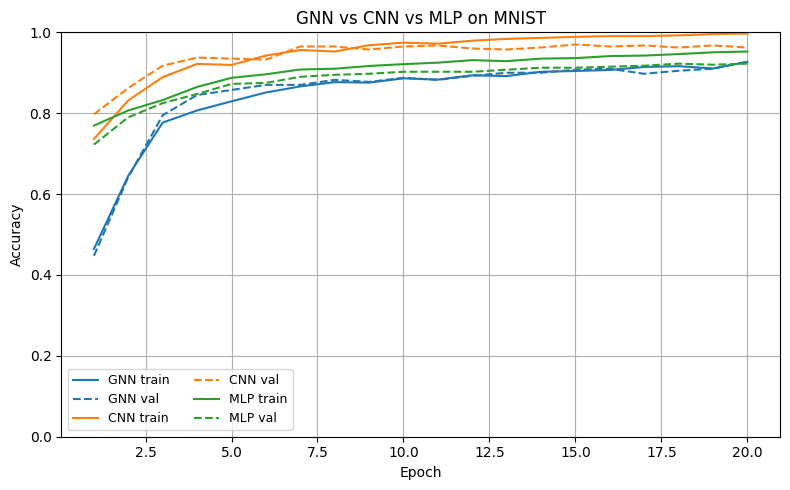


Model parameter counts:
Model                              Parameters
----------------------------------------------
GNN (3 x GCNConv + FC)                 47,158
CNN (2 x Conv2d + FC)                  50,186
MLP (1 hidden layer)                   50,890

Test accuracy: GNN = 0.8820  CNN = 0.9680  MLP = 0.8780


In [53]:
fig, ax = plt.subplots(figsize=(8, 5))
epochs = range(1, N_EPOCHS + 1)
for name, tr, va, color in [
        ('GNN', gnn_train_accs, gnn_val_accs, 'tab:blue'),
        ('CNN', cnn_train_accs, cnn_val_accs, 'tab:orange'),
        ('MLP', mlp_train_accs, mlp_val_accs, 'tab:green')]:
    ax.plot(epochs, tr, color=color, linestyle='-',  linewidth=1.5, label=f'{name} train')
    ax.plot(epochs, va, color=color, linestyle='--', linewidth=1.5, label=f'{name} val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title('GNN vs CNN vs MLP on MNIST')
ax.set_ylim(0, 1); ax.legend(ncol=2, fontsize=9); ax.grid(True)
plt.tight_layout(); plt.show()

print("\nModel parameter counts:")
print(f"{'Model':<32} {'Parameters':>12}")
print("-" * 46)
for name, m in [('GNN (3 x GCNConv + FC)', gnn_mnist),
                ('CNN (2 x Conv2d + FC)',        cnn_mnist),
                ('MLP (1 hidden layer)',          mlp_mnist)]:
    print(f"{name:<32} {count_params(m):>12,}")

print(f"\nTest accuracy: GNN = {gnn_test_acc:.4f}  CNN = {cnn_test_acc:.4f}  MLP = {mlp_test_acc:.4f}")

**Question 9.** All three models have roughly the same parameter count (~50K).
- Rank their test accuracy from highest to lowest.
- Explain the results

We observe that the rank by accuracy is:
  
    1 - CNN  - 97,0%
    2 - MLP  - 88,8%
    3 - GNN - 86,8%

The best performance from CNN is expected as CNN's were designed to perform well on this kind of problem. The convolution filters capture relevant information about a set of pixels, which gives a deeper and more relevant understanding of the image to the model.

The MLP comes in second place. This model do not consider pixel's positions or neighbors, but since MNIST is relatively simple dataset, it still achieves second best performance.

Finally, the GNN's have the worst performance. Even though an image can be interpreted as a graph, the GNN representation and message passsing assumes a structure representation that is not perfectly thought for images. That means that, although images can be seen in this graph structure and give good results, CNNs have a better image representation.